SAMAGRA GUPTA 590014891 B12 AIML LAB 

EXPERIMENT 2

In [1]:
import numpy as np              
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("Housing.csv")
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


In [4]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)
df = df.astype(float)


In [5]:
X = df.drop("price", axis=1).values
y = df["price"].values.reshape(-1, 1)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


In [8]:
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

In [9]:
def compute_loss(X, y, beta):
    predictions = X @ beta
    return np.mean((y - predictions) ** 2)

In [10]:
def batch_gradient_descent(X, y, lr=0.01, epochs=500):

    m, n = X.shape
    beta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(epochs):
        predictions = X @ beta
        gradient = (-2/m) * X.T @ (y - predictions)
        beta = beta - lr * gradient
        loss_history.append(compute_loss(X, y, beta))

    return beta, loss_history

In [11]:
def mini_batch_gradient_descent(X, y, lr=0.01, epochs=500, batch_size=32):

    m, n = X.shape
    beta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            batch_m = len(X_batch)
            predictions = X_batch @ beta
            gradient = (-2/batch_m) * X_batch.T @ (y_batch - predictions)
            beta = beta - lr * gradient

        loss_history.append(compute_loss(X, y, beta))

    return beta, loss_history


In [ ]:
beta_bgd, loss_bgd = batch_gradient_descent(X_train, y_train)

beta_mbgd, loss_mbgd = mini_batch_gradient_descent(
    X_train, y_train, batch_size=32
)


In [13]:
y_pred_bgd = X_test @ beta_bgd
y_pred_mbgd = X_test @ beta_mbgd


In [14]:
print("\nBatch Gradient Descent Coefficients:")
for i, b in enumerate(beta_bgd):
    print(f"Beta {i}: {b[0]}")

print("\nMini-Batch Gradient Descent Coefficients:")
for i, b in enumerate(beta_mbgd):
    print(f"Beta {i}: {b[0]}")


Batch Gradient Descent Coefficients:
Beta 0: 4706334.304811557
Beta 1: 518342.00652190426
Beta 2: 59147.80729540323
Beta 3: 521746.07526788977
Beta 4: 347154.68654754834
Beta 5: 129445.31618282206
Beta 6: 89977.93436308038
Beta 7: 185352.973704412
Beta 8: 150093.4775743037
Beta 9: 366023.2300486278
Beta 10: 192232.37242049852
Beta 11: 266631.08845909085
Beta 12: -62040.35409229217
Beta 13: -191230.6299386749

Mini-Batch Gradient Descent Coefficients:
Beta 0: 4711857.399336119
Beta 1: 519880.8029801314
Beta 2: 63552.6439802432
Beta 3: 524184.4584686476
Beta 4: 349061.66443769785
Beta 5: 131198.86728114297
Beta 6: 98903.0751377174
Beta 7: 195058.28419863555
Beta 8: 152962.33215364558
Beta 9: 366191.12169180904
Beta 10: 194872.17546112396
Beta 11: 266622.1415227169
Beta 12: -65047.6575697196
Beta 13: -198848.81626421897


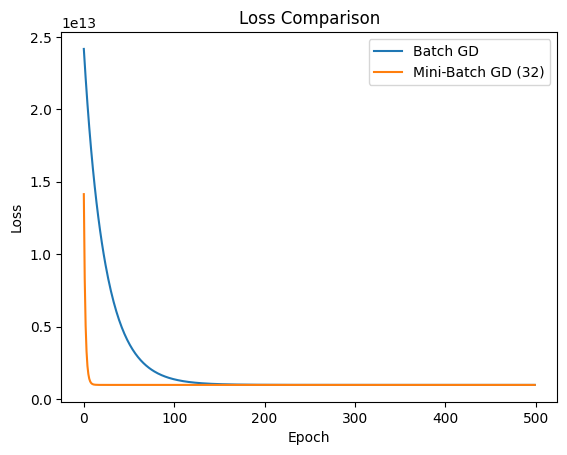

In [15]:
plt.figure()

plt.plot(loss_bgd, label="Batch GD")
plt.plot(loss_mbgd, label="Mini-Batch GD (32)")

plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


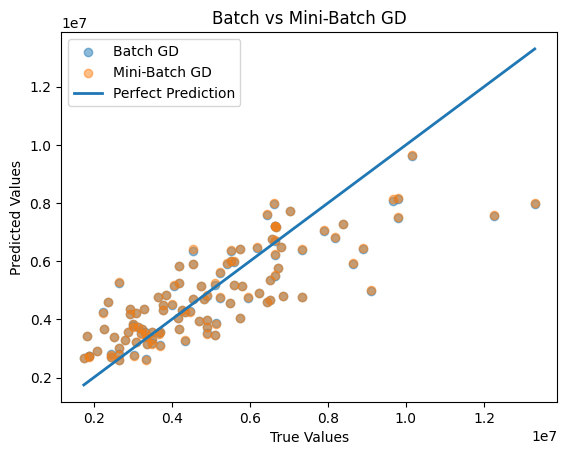

In [16]:
plt.figure()

plt.scatter(y_test, y_pred_bgd, alpha=0.5, label="Batch GD")
plt.scatter(y_test, y_pred_mbgd, alpha=0.5, label="Mini-Batch GD")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Batch vs Mini-Batch GD")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()


In [17]:
print("\nBatch Gradient Descent Performance")

print("R2:", r2_score(y_test, y_pred_bgd))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_bgd)))
print("MAE:", mean_absolute_error(y_test, y_pred_bgd))


print("\nMini-Batch Gradient Descent Performance")

print("R2:", r2_score(y_test, y_pred_mbgd))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mbgd)))
print("MAE:", mean_absolute_error(y_test, y_pred_mbgd))



Batch Gradient Descent Performance
R2: 0.6530275926451725
RMSE: 1324309.7849534752
MAE: 969394.3353598682

Mini-Batch Gradient Descent Performance
R2: 0.6552987659924057
RMSE: 1319968.409204656
MAE: 968561.4680811872
